In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import pdfplumber

In [2]:
def biexp_speed(t, Vmax, tau1, tau2):
    return Vmax * (np.exp(-t / tau2) - np.exp(-t / tau1))

def biexp_position(t, Vmax, tau1, tau2):
    # Integral de la velocidad biexponencial
    # ∫ Vmax * (e^(-t/tau2) - e^(-t/tau1)) dt
    # = Vmax * (-tau2 * e^(-t/tau2) + tau1 * e^(-t/tau1)) + C
    # Con C tal que position(0) = 0
    return Vmax * (
        -tau2 * np.exp(-t / tau2) + tau1 * np.exp(-t / tau1) - (tau1 - tau2)
    )

In [3]:
# Extraer datos del PDF de la final de 100m de París 2024
pdf_path = "Paris_2024-100m_Final.pdf"

with pdfplumber.open(pdf_path) as pdf:
    # Imprimir el texto de todas las páginas para ver la estructura
    for i, page in enumerate(pdf.pages):
        print(f"\n--- Página {i+1} ---")
        print(page.extract_text())
        print("\n")
        
        # Intentar extraer tablas
        tables = page.extract_tables()
        if tables:
            print(f"Tablas encontradas en página {i+1}:")
            for j, table in enumerate(tables):
                print(f"\nTabla {j+1}:")
                df = pd.DataFrame(table[1:], columns=table[0])
                print(df)

CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox



--- Página 1 ---
Stade de France Athletics
Stade de France Athlétisme
Men's 100m
100 m - hommes
SUN 4 AUG 2024 Final
Start Time 21:50 Finale
Results
Résultats
WORLD RECORD 9.58 BOLT Usain JAM Berlin (GER) 16 AUG 2009
OLYMPIC RECORD 9.63 BOLT Usain JAM London (GBR) 5 AUG 2012
Wind: +1.0m/s
Athlete NOC Reaction
Rank Name Date of Birth Lane Result
Bib Code Time
1 1328 LYLES Noah USA 18 JUL 1997 7 0.178 9.79 (.784) PB
2 915 THOMPSON Kishane JAM 17 JUL 2001 4 0.176 9.79 (.789)
3 1319 KERLEY Fred USA 7 MAY 1995 3 0.108 9.81 SB
4 1191 SIMBINE Akani RSA 21 SEP 1993 5 0.149 9.82 NR
5 856 JACOBS Lamont Marcell ITA 26 SEP 1994 9 0.114 9.85 SB
6 415 TEBOGO Letsile BOT 7 JUN 2003 8 0.178 9.86 NR
7 1292 BEDNAREK Kenneth USA 14 OCT 1998 2 0.163 9.88
8 912 SEVILLE Oblique JAM 16 MAR 2001 6 0.171 9.91
Weather conditions
Temperature: 22 °C Humidity: 48 % Conditions: Sunny intervals
Legend:
NR National Record PB Personal Best SB Season Best
ATHM100M--------------FNL-000100--_73B1 v1.0 Report Created SUN

In [4]:
# Extraer datos manualmente desde las tablas que ya vimos
# Datos de la Final 100m París 2024

names = ["LYLES", "THOMPSON", "BEDNAREK", "SEVILLE", "TEBOGO", "BAILEY", "KERLEY", "HUGHES"]

# Tiempos de reacción y splits extraídos del PDF
athletes_data = {
    'LYLES': {
        'reaction_time': 0.178,
        'splits_10m': [1.95, 2.98, 3.90, 4.76, 5.61, 6.44, 7.26, 8.09, 8.93, 9.79]
    },
    'THOMPSON': {
        'reaction_time': 0.158,  
        'splits_10m': [1.90, 2.93, 3.84, 4.72, 5.56, 6.41, 7.24, 8.07, 8.92, 9.79]
    },
    'BEDNAREK': {
        'reaction_time': 0.145,
        'splits_10m': [1.87, 2.92, 3.85, 4.73, 5.58, 6.41, 7.25, 8.09, 8.94, 9.81]
    },
    'SEVILLE': {
        'reaction_time': 0.144,
        'splits_10m': [1.90, 2.95, 3.87, 4.75, 5.60, 6.46, 7.27, 8.11, 8.96, 9.82]
    },
    'TEBOGO': {
        'reaction_time': 0.147,
        'splits_10m': [1.87, 2.92, 3.85, 4.74, 5.60, 6.44, 7.28, 8.13, 8.98, 9.85]
    },
    'BAILEY': {
        'reaction_time': 0.156,
        'splits_10m': [1.90, 2.94, 3.87, 4.75, 5.61, 6.45, 7.29, 8.13, 8.98, 9.86]
    },
    'KERLEY': {
        'reaction_time': 0.144,
        'splits_10m': [1.91, 2.96, 3.88, 4.75, 5.61, 6.46, 7.29, 8.14, 9.00, 9.88]
    },
    'HUGHES': {
        'reaction_time': 0.146,
        'splits_10m': [1.89, 2.94, 3.87, 4.75, 5.60, 6.45, 7.29, 8.13, 9.00, 9.91]
    },
    'BOLT': {
        'reaction_time': 0.146,
        'splits_10m': [1.89, 2.88, 3.78, 4.64, 5.47, 6.29, 7.10, 7.92, 8.75, 9.58]  # Usado para comparación
    }
}

# Crear un DataFrame más legible
data_list = []
for name in names:
    data = athletes_data[name]
    data_list.append({
        'Athlete': name,
        'Reaction_Time': data['reaction_time'],
        '10m': data['splits_10m'][0],
        '20m': data['splits_10m'][1],
        '30m': data['splits_10m'][2],
        '40m': data['splits_10m'][3],
        '50m': data['splits_10m'][4],
        '60m': data['splits_10m'][5],
        '70m': data['splits_10m'][6],
        '80m': data['splits_10m'][7],
        '90m': data['splits_10m'][8],
        '100m': data['splits_10m'][9]
    })

df_paris_2024 = pd.DataFrame(data_list)
print("Tiempos de reacción y splits de 10m - Final 100m París 2024\n")
print(df_paris_2024.to_string(index=False))

# También crear arrays de numpy para análisis posterior
print("\n\nDatos en formato numpy arrays:")
for name in names:
    data = athletes_data[name]
    print(f"\n{name}:")
    print(f"  reaction_time = {data['reaction_time']}")
    print(f"  splits_10m = np.array({data['splits_10m']})")

Tiempos de reacción y splits de 10m - Final 100m París 2024

 Athlete  Reaction_Time  10m  20m  30m  40m  50m  60m  70m  80m  90m  100m
   LYLES          0.178 1.95 2.98 3.90 4.76 5.61 6.44 7.26 8.09 8.93  9.79
THOMPSON          0.158 1.90 2.93 3.84 4.72 5.56 6.41 7.24 8.07 8.92  9.79
BEDNAREK          0.145 1.87 2.92 3.85 4.73 5.58 6.41 7.25 8.09 8.94  9.81
 SEVILLE          0.144 1.90 2.95 3.87 4.75 5.60 6.46 7.27 8.11 8.96  9.82
  TEBOGO          0.147 1.87 2.92 3.85 4.74 5.60 6.44 7.28 8.13 8.98  9.85
  BAILEY          0.156 1.90 2.94 3.87 4.75 5.61 6.45 7.29 8.13 8.98  9.86
  KERLEY          0.144 1.91 2.96 3.88 4.75 5.61 6.46 7.29 8.14 9.00  9.88
  HUGHES          0.146 1.89 2.94 3.87 4.75 5.60 6.45 7.29 8.13 9.00  9.91


Datos en formato numpy arrays:

LYLES:
  reaction_time = 0.178
  splits_10m = np.array([1.95, 2.98, 3.9, 4.76, 5.61, 6.44, 7.26, 8.09, 8.93, 9.79])

THOMPSON:
  reaction_time = 0.158
  splits_10m = np.array([1.9, 2.93, 3.84, 4.72, 5.56, 6.41, 7.24, 8.07, 8.92, 9

In [5]:
# Seleccionar atleta para análisis (LYLES - Ganador de oro)
athlete_name = "BOLT"
athlete_data = athletes_data[athlete_name]

reaction_time = athlete_data['reaction_time']
times_10m = np.array(athlete_data['splits_10m'])
times_10m = np.insert(times_10m, 0, reaction_time)  # Incluir tiempo de reacción al inicio

# Calcular tiempos desde el inicio (incluyendo tiempo de reacción)
t = times_10m.copy()

# Calcular velocidades instantáneas (m/s) desde los splits
# velocidad = distancia / tiempo
distances = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
v = np.zeros(len(times_10m))

# Velocidad en cada intervalo
for i in range(len(times_10m)):
    if i == 0:
        v[i] = 0  # Velocidad inicial es 0
        t[i] = reaction_time # Tiempo inicial es tiempo de reacción
    else:
        v[i] = (distances[i] - distances[i-1]) / (times_10m[i] - times_10m[i-1])
        t[i] = (times_10m[i]-times_10m[i-1]) / 2 + times_10m[i-1]  # Ajustar tiempo al inicio real

print(f"Análisis de {athlete_name}")
print(f"Tiempo de reacción: {reaction_time:.3f} s")
print(f"Tiempo total: {times_10m[-1]:.2f} s")
print(f"\nTiempos (s): {t}")
print(f"Velocidades (m/s): {np.round(v, 2)}")

Análisis de BOLT
Tiempo de reacción: 0.146 s
Tiempo total: 9.58 s

Tiempos (s): [0.146 1.018 2.385 3.33  4.21  5.055 5.88  6.695 7.51  8.335 9.165]
Velocidades (m/s): [ 0.    5.73 10.1  11.11 11.63 12.05 12.2  12.35 12.2  12.05 12.05]


In [6]:
p0 = [10, 0.5, 20]  # Vmax, tau1, tau2

# límites para mantener sentido fisiológico
bounds = ([0, 0.01, 0.1], [300, 10, 200])

params, cov = curve_fit(
    biexp_speed,
    t,
    v,
    p0=p0,
    bounds=bounds
)

Vmax, tau1, tau2 = params

print(f"Vmax  = {Vmax:.2f} m/s")
print(f"tau1  = {tau1:.2f} s")
print(f"tau2  = {tau2:.2f} s")

Vmax  = 14.57 m/s
tau1  = 1.90 s
tau2  = 48.69 s


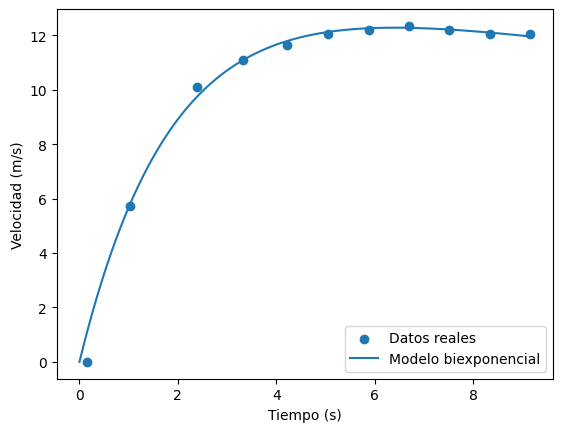

In [7]:
t_fit = np.linspace(0, t.max(), 300)
v_fit = biexp_speed(t_fit, Vmax, tau1, tau2)

plt.scatter(t, v, label="Datos reales")
plt.plot(t_fit, v_fit, label="Modelo biexponencial")
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (m/s)")
plt.legend()
plt.show()

In [8]:
t_peak = (tau1 * tau2 / (tau2 - tau1)) * np.log(tau2 / tau1)
v_peak = biexp_speed(t_peak, Vmax, tau1, tau2)

print(f"t_vmax = {t_peak:.2f} s")
print(f"v_max  = {v_peak:.2f} m/s")

t_vmax = 6.40 s
v_max  = 12.28 m/s


## Análisis Comparativo de Todos los Finalistas

Ajustaremos el modelo biexponencial para los 8 finalistas y compararemos sus perfiles de velocidad.

In [9]:
# Función para calcular velocidades desde splits
def calculate_velocities(splits, reaction_time):
    times_10m = np.array(splits)
    distances = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    v = np.zeros(len(times_10m))
    t = times_10m.copy()
    
    for i in range(len(times_10m)):
        if i == 0:
            v[i] = 0  # Velocidad inicial es 0
            t[i] = reaction_time # Tiempo inicial es tiempo de reacción
        else:
            v[i] = (distances[i] - distances[i-1]) / (times_10m[i] - times_10m[i-1])
            t[i] = (times_10m[i]-times_10m[i-1]) / 2 + times_10m[i-1]  # Ajustar tiempo al inicio real
    
    return t, v

# Ajustar modelo biexponencial para todos los atletas
all_results = {}

for name in names:
    data = athletes_data[name]
    reaction_time = data['reaction_time']
    times_10m = np.array(data['splits_10m'])
    times_10m = np.insert(times_10m, 0, reaction_time)
    t_athlete, v_athlete = calculate_velocities(times_10m, data['reaction_time'])
    
    # Ajustar modelo
    try:
        p0 = [12, 1.0, 20]
        bounds = ([0, 0.01, 0.1], [200, 10, 200])
        params, cov = curve_fit(biexp_speed, t_athlete, v_athlete, p0=p0, bounds=bounds)
        
        Vmax_fit, tau1_fit, tau2_fit = params
        
        # Calcular velocidad máxima y tiempo al que se alcanza
        t_peak = (tau1_fit * tau2_fit / (tau2_fit - tau1_fit)) * np.log(tau2_fit / tau1_fit)
        v_peak = biexp_speed(t_peak, Vmax_fit, tau1_fit, tau2_fit)
        
        all_results[name] = {
            'reaction_time': data['reaction_time'],
            'finish_time': data['splits_10m'][-1],
            't': t_athlete,
            'v': v_athlete,
            'Vmax': Vmax_fit,
            'tau1': tau1_fit,
            'tau2': tau2_fit,
            't_vmax': t_peak,
            'v_max': v_peak,
            'params': params
        }
    except Exception as e:
        print(f"Error ajustando {name}: {e}")

print("Modelos ajustados exitosamente para todos los atletas")

Modelos ajustados exitosamente para todos los atletas


In [10]:
# Crear DataFrame con resumen de parámetros
summary_data = []
for name in names:
    if name in all_results:
        res = all_results[name]
        summary_data.append({
            'Atleta': name,
            'T_Reacción (s)': res['reaction_time'],
            'T_Final (s)': res['finish_time'],
            'Vmax_modelo (m/s)': res['Vmax'],
            'tau1 (s)': res['tau1'],
            'tau2 (s)': res['tau2'],
            't_vmax (s)': res['t_vmax'],
            'v_max (m/s)': res['v_max']
        })

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.round(3)

print("Parámetros del Modelo Biexponencial - Final 100m París 2024")
print("=" * 100)
print(df_summary.to_string(index=False))
print("\n")

# Ordenar por velocidad máxima
df_summary_sorted = df_summary.sort_values('v_max (m/s)', ascending=False)
print("\nAtletas ordenados por velocidad máxima alcanzada:")
print("=" * 100)
print(df_summary_sorted[['Atleta', 'v_max (m/s)', 't_vmax (s)', 'T_Final (s)']].to_string(index=False))

Parámetros del Modelo Biexponencial - Final 100m París 2024
  Atleta  T_Reacción (s)  T_Final (s)  Vmax_modelo (m/s)  tau1 (s)  tau2 (s)  t_vmax (s)  v_max (m/s)
   LYLES           0.178         9.79             15.912     2.233    32.116       6.398       12.131
THOMPSON           0.158         9.79             14.785     1.986    39.800       6.267       12.001
BEDNAREK           0.145         9.81             14.285     1.923    46.505       6.391       11.936
 SEVILLE           0.144         9.82             14.171     1.943    50.627       6.587       11.964
  TEBOGO           0.147         9.85             13.658     1.827    58.974       6.552       11.844
  BAILEY           0.156         9.86             14.476     1.972    42.711       6.358       11.898
  KERLEY           0.144         9.88             14.965     2.042    36.353       6.229       11.900
  HUGHES           0.146         9.91             15.751     2.126    28.981       5.993       11.869



Atletas ordenados p

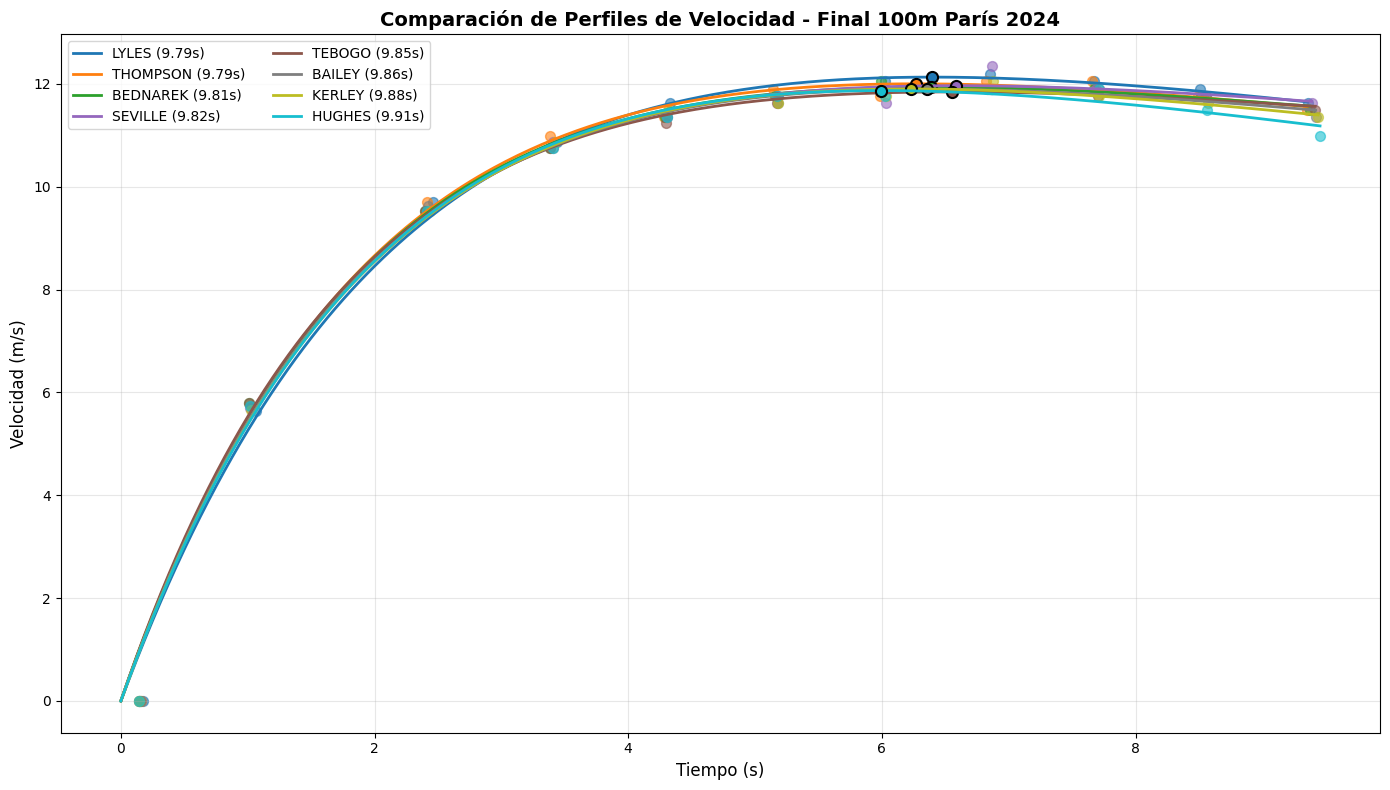

In [11]:
# Visualización comparativa de curvas de velocidad
plt.figure(figsize=(14, 8))

# Definir colores para cada atleta
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for idx, name in enumerate(names):
    if name in all_results:
        res = all_results[name]
        
        # Datos reales
        plt.scatter(res['t'], res['v'], color=colors[idx], alpha=0.6, s=50)
        
        # Modelo ajustado
        t_fit = np.linspace(0, res['t'].max(), 300)
        v_fit = biexp_speed(t_fit, res['Vmax'], res['tau1'], res['tau2'])
        plt.plot(t_fit, v_fit, color=colors[idx], label=f"{name} ({res['finish_time']:.2f}s)", linewidth=2)
        
        # Marcar velocidad máxima
        plt.plot(res['t_vmax'], res['v_max'], 'o', color=colors[idx], markersize=8, 
                markeredgecolor='black', markeredgewidth=1.5)

plt.xlabel('Tiempo (s)', fontsize=12)
plt.ylabel('Velocidad (m/s)', fontsize=12)
plt.title('Comparación de Perfiles de Velocidad - Final 100m París 2024', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

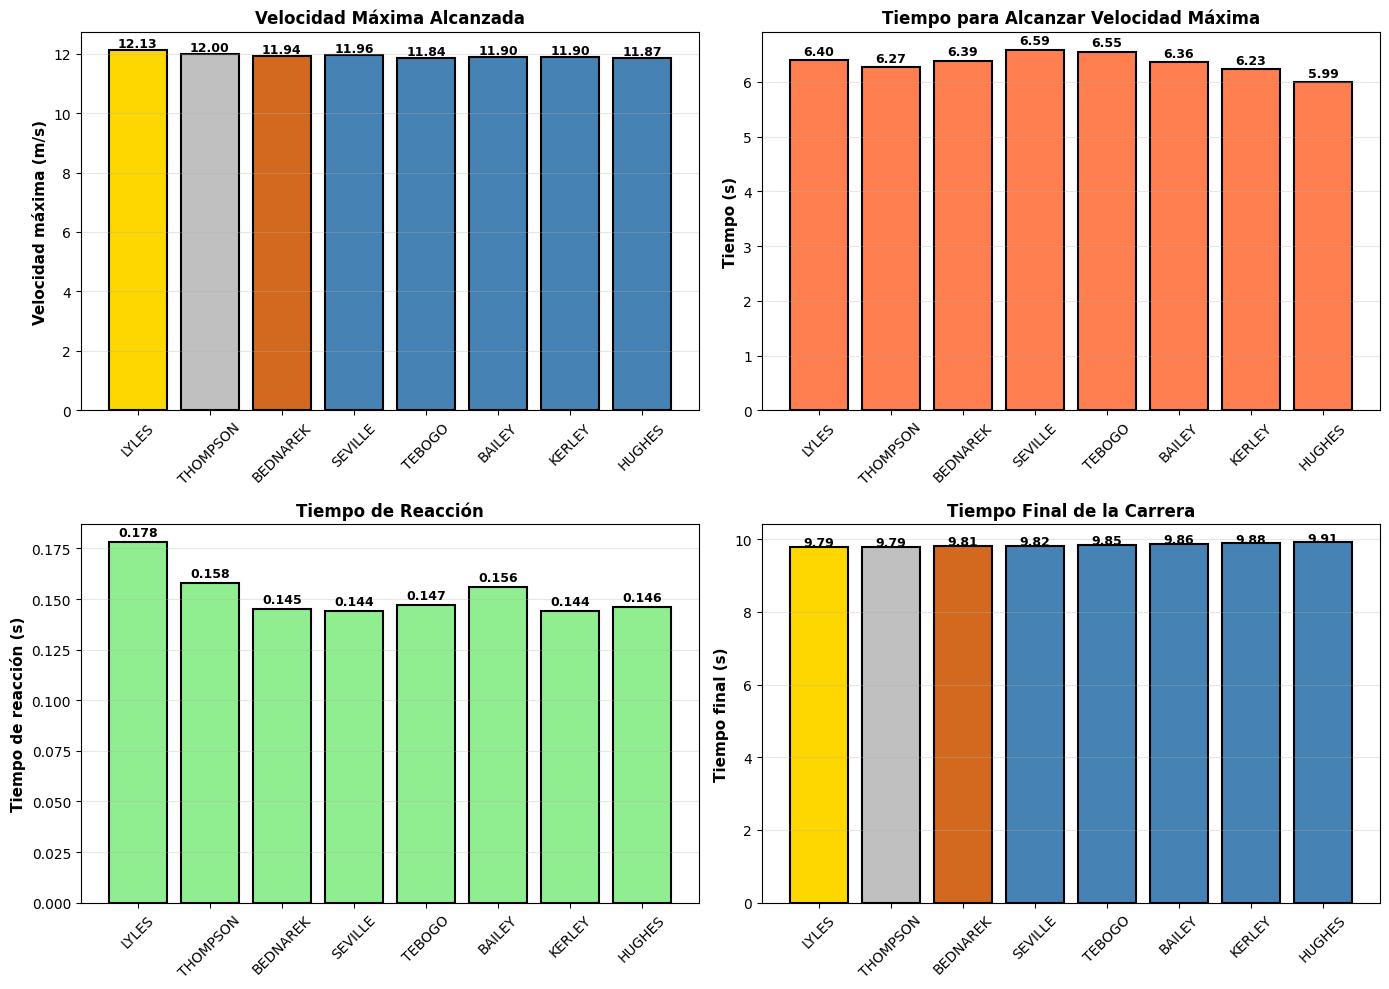

In [12]:
# Gráficos comparativos de métricas clave
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Velocidad máxima alcanzada
ax1 = axes[0, 0]
v_max_values = [all_results[name]['v_max'] for name in names]
colors_bars = ['gold' if i == 0 else 'silver' if i == 1 else 'chocolate' if i == 2 else 'steelblue' 
               for i, _ in enumerate(names)]
bars1 = ax1.bar(names, v_max_values, color=colors_bars, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Velocidad máxima (m/s)', fontsize=11, fontweight='bold')
ax1.set_title('Velocidad Máxima Alcanzada', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(v_max_values):
    ax1.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

# 2. Tiempo al que se alcanza v_max
ax2 = axes[0, 1]
t_vmax_values = [all_results[name]['t_vmax'] for name in names]
bars2 = ax2.bar(names, t_vmax_values, color='coral', edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Tiempo (s)', fontsize=11, fontweight='bold')
ax2.set_title('Tiempo para Alcanzar Velocidad Máxima', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
for i, t in enumerate(t_vmax_values):
    ax2.text(i, t + 0.1, f'{t:.2f}', ha='center', fontsize=9, fontweight='bold')

# 3. Tiempo de reacción
ax3 = axes[1, 0]
reaction_times = [all_results[name]['reaction_time'] for name in names]
bars3 = ax3.bar(names, reaction_times, color='lightgreen', edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Tiempo de reacción (s)', fontsize=11, fontweight='bold')
ax3.set_title('Tiempo de Reacción', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=45)
for i, rt in enumerate(reaction_times):
    ax3.text(i, rt + 0.003, f'{rt:.3f}', ha='center', fontsize=9, fontweight='bold')

# 4. Tiempo final
ax4 = axes[1, 1]
finish_times = [all_results[name]['finish_time'] for name in names]
bars4 = ax4.bar(names, finish_times, color=colors_bars, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Tiempo final (s)', fontsize=11, fontweight='bold')
ax4.set_title('Tiempo Final de la Carrera', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', rotation=45)
for i, ft in enumerate(finish_times):
    ax4.text(i, ft + 0.02, f'{ft:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# Análisis de correlaciones
print("ANÁLISIS DE CORRELACIONES")
print("=" * 80)

# Correlación entre velocidad máxima y tiempo final
v_max_arr = np.array([all_results[name]['v_max'] for name in names])
finish_time_arr = np.array([all_results[name]['finish_time'] for name in names])
corr_v_time = np.corrcoef(v_max_arr, finish_time_arr)[0, 1]

print(f"\nCorrelación entre velocidad máxima y tiempo final: {corr_v_time:.3f}")

# Correlación entre tiempo de reacción y tiempo final
reaction_arr = np.array([all_results[name]['reaction_time'] for name in names])
corr_react_time = np.corrcoef(reaction_arr, finish_time_arr)[0, 1]

print(f"Correlación entre tiempo de reacción y tiempo final: {corr_react_time:.3f}")

# Correlación entre tiempo a v_max y tiempo final
t_vmax_arr = np.array([all_results[name]['t_vmax'] for name in names])
corr_tvmax_time = np.corrcoef(t_vmax_arr, finish_time_arr)[0, 1]

print(f"Correlación entre tiempo a v_max y tiempo final: {corr_tvmax_time:.3f}")

# Estadísticas descriptivas
print(f"\n\nESTADÍSTICAS DESCRIPTIVAS")
print("=" * 80)
print(f"Velocidad máxima promedio: {v_max_arr.mean():.2f} ± {v_max_arr.std():.2f} m/s")
print(f"Velocidad máxima rango: {v_max_arr.min():.2f} - {v_max_arr.max():.2f} m/s")
print(f"\nTiempo a v_max promedio: {t_vmax_arr.mean():.2f} ± {t_vmax_arr.std():.2f} s")
print(f"Tiempo a v_max rango: {t_vmax_arr.min():.2f} - {t_vmax_arr.max():.2f} s")
print(f"\nTiempo de reacción promedio: {reaction_arr.mean():.3f} ± {reaction_arr.std():.3f} s")
print(f"Tiempo de reacción rango: {reaction_arr.min():.3f} - {reaction_arr.max():.3f} s")

# Diferencia entre primer y último lugar
time_diff = finish_time_arr.max() - finish_time_arr.min()
print(f"\nDiferencia entre 1° y 8° lugar: {time_diff:.2f} s")

ANÁLISIS DE CORRELACIONES

Correlación entre velocidad máxima y tiempo final: -0.764
Correlación entre tiempo de reacción y tiempo final: -0.541
Correlación entre tiempo a v_max y tiempo final: -0.553


ESTADÍSTICAS DESCRIPTIVAS
Velocidad máxima promedio: 11.94 ± 0.09 m/s
Velocidad máxima rango: 11.84 - 12.13 m/s

Tiempo a v_max promedio: 6.35 ± 0.18 s
Tiempo a v_max rango: 5.99 - 6.59 s

Tiempo de reacción promedio: 0.152 ± 0.011 s
Tiempo de reacción rango: 0.144 - 0.178 s

Diferencia entre 1° y 8° lugar: 0.12 s


## Análisis de Posiciones vs Tiempo

Usando la función de posición biexponencial para visualizar la progresión de cada atleta a lo largo de la carrera.

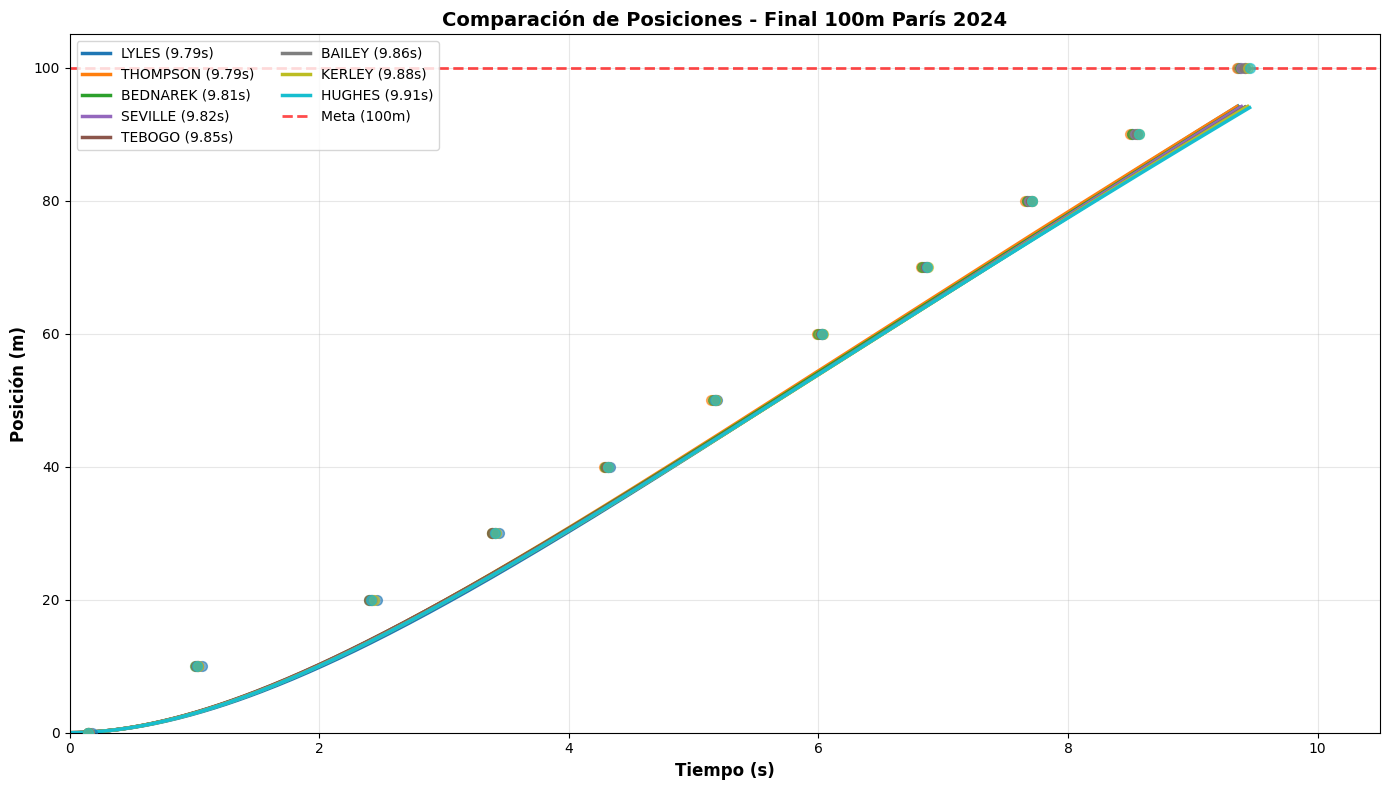

In [14]:
# Calcular y graficar posiciones para todos los atletas
plt.figure(figsize=(14, 8))

# Definir colores para cada atleta
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for idx, name in enumerate(names):
    if name in all_results:
        res = all_results[name]
        
        # Calcular posiciones reales desde los datos
        distances = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
        plt.scatter(res['t'], distances, color=colors[idx], alpha=0.6, s=50, zorder=3)
        
        # Modelo de posición ajustado
        t_fit = np.linspace(0, res['t'].max(), 300)
        x_fit = biexp_position(t_fit, res['Vmax'], res['tau1'], res['tau2'])
        plt.plot(t_fit, x_fit, color=colors[idx], label=f"{name} ({res['finish_time']:.2f}s)", linewidth=2.5)

# Línea de meta
plt.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Meta (100m)', alpha=0.7)

plt.xlabel('Tiempo (s)', fontsize=12, fontweight='bold')
plt.ylabel('Posición (m)', fontsize=12, fontweight='bold')
plt.title('Comparación de Posiciones - Final 100m París 2024', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10, ncol=2)
plt.grid(True, alpha=0.3)
plt.xlim(0, 10.5)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

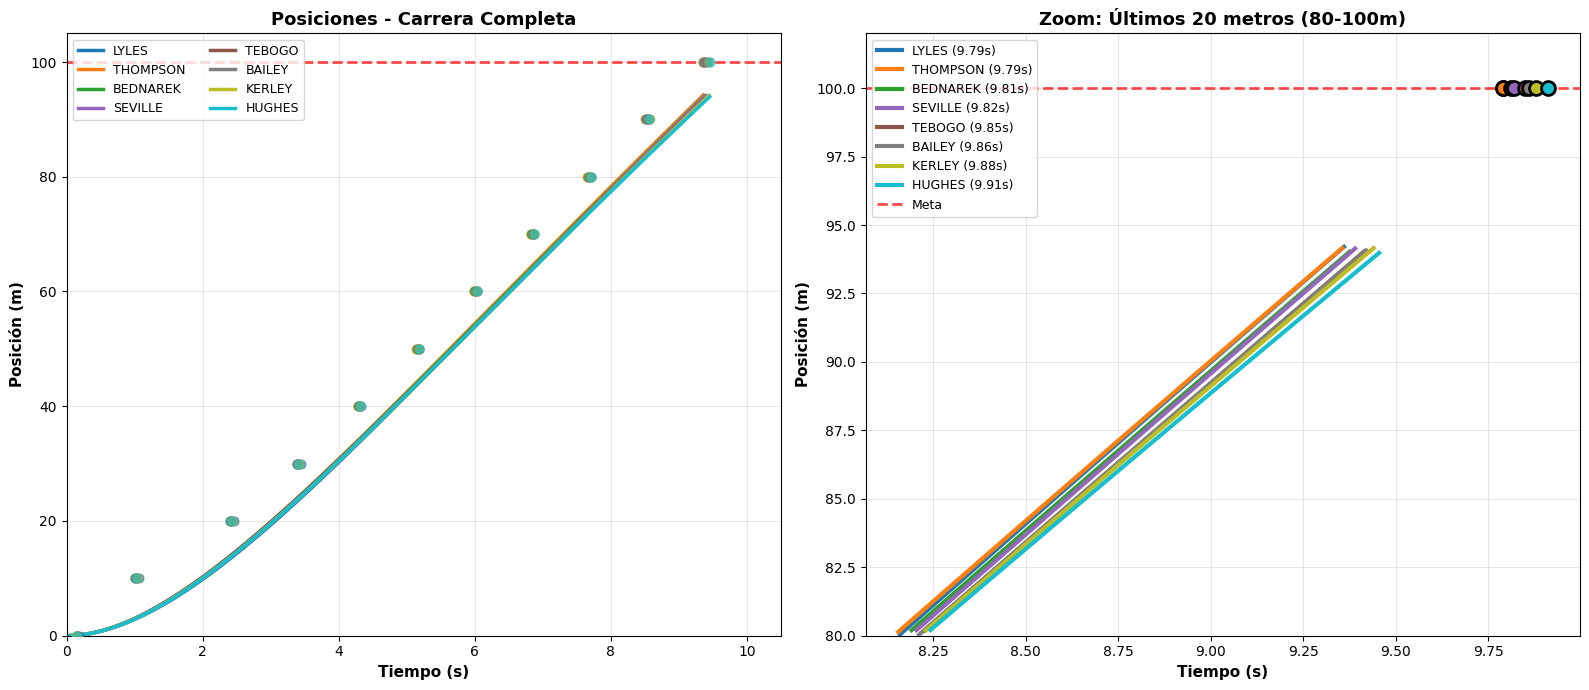

In [15]:
# Gráfico comparativo: Posición vs Tiempo con zoom en el final
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

colors = plt.cm.tab10(np.linspace(0, 1, 8))
distances = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

# Panel 1: Carrera completa
for idx, name in enumerate(names):
    if name in all_results:
        res = all_results[name]
        
        # Datos reales
        ax1.scatter(res['t'], distances, color=colors[idx], alpha=0.6, s=40, zorder=3)
        
        # Modelo
        t_fit = np.linspace(0, res['t'].max(), 300)
        x_fit = biexp_position(t_fit, res['Vmax'], res['tau1'], res['tau2'])
        ax1.plot(t_fit, x_fit, color=colors[idx], label=f"{name}", linewidth=2.5)

ax1.axhline(y=100, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel('Tiempo (s)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Posición (m)', fontsize=11, fontweight='bold')
ax1.set_title('Posiciones - Carrera Completa', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 10.5)
ax1.set_ylim(0, 105)

# Panel 2: Zoom en los últimos 20 metros
for idx, name in enumerate(names):
    if name in all_results:
        res = all_results[name]
        
        # Modelo completo
        t_fit = np.linspace(0, res['t'].max(), 500)
        x_fit = biexp_position(t_fit, res['Vmax'], res['tau1'], res['tau2'])
        
        # Filtrar solo la región de 80-100m
        mask = (x_fit >= 80) & (x_fit <= 100)
        ax2.plot(t_fit[mask], x_fit[mask], color=colors[idx], label=f"{name} ({res['finish_time']:.2f}s)", linewidth=3)
        
        # Marcar el punto final
        ax2.plot(res['finish_time'], 100, 'o', color=colors[idx], markersize=10, 
                markeredgecolor='black', markeredgewidth=2, zorder=5)

ax2.axhline(y=100, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Meta')
ax2.set_xlabel('Tiempo (s)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Posición (m)', fontsize=11, fontweight='bold')
ax2.set_title('Zoom: Últimos 20 metros (80-100m)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(80, 102)

plt.tight_layout()
plt.show()

In [16]:
# Tabla de posiciones en momentos clave de la carrera
print("POSICIONES EN MOMENTOS CLAVE DE LA CARRERA")
print("=" * 100)

# Tiempos clave: 2s, 4s, 6s, 8s, y tiempo final
key_times = [2, 4, 6, 8]

positions_at_times = {}
for name in names:
    if name in all_results:
        res = all_results[name]
        positions_at_times[name] = []
        
        for t_key in key_times:
            # Calcular posición en ese tiempo
            if t_key <= res['finish_time']:
                pos = biexp_position(t_key, res['Vmax'], res['tau1'], res['tau2'])
                positions_at_times[name].append(pos)
            else:
                positions_at_times[name].append(100)  # Ya terminó

# Crear DataFrame
positions_df = pd.DataFrame(positions_at_times, index=[f'{t}s' for t in key_times]).T
positions_df['Final'] = [all_results[name]['finish_time'] for name in names]
positions_df = positions_df.round(2)

print("\nPosición (metros) en cada momento:")
print(positions_df.to_string())

# Analizar gaps entre atletas al final
print("\n\nDIFERENCIAS EN LA META")
print("=" * 100)

final_times_sorted = sorted([(name, all_results[name]['finish_time']) for name in names], 
                            key=lambda x: x[1])

print(f"{'Lugar':<7} {'Atleta':<12} {'Tiempo (s)':<12} {'Diferencia con 1°':<18} {'Diferencia con anterior':<20}")
print("-" * 100)

for i, (name, time) in enumerate(final_times_sorted, 1):
    diff_first = time - final_times_sorted[0][1] if i > 1 else 0
    diff_prev = time - final_times_sorted[i-2][1] if i > 1 else 0
    
    medal = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"{medal} {i:<5} {name:<12} {time:<12.2f} {diff_first:<18.3f} {diff_prev:<20.3f}")

POSICIONES EN MOMENTOS CLAVE DE LA CARRERA

Posición (metros) en cada momento:
             2s     4s     6s     8s  Final
LYLES      9.83  30.24  53.97  78.14   9.79
THOMPSON  10.20  30.82  54.41  78.31   9.79
BEDNAREK  10.20  30.71  54.15  77.95   9.81
SEVILLE   10.09  30.48  53.90  77.78   9.82
TEBOGO    10.25  30.66  53.90  77.53   9.85
BAILEY    10.09  30.48  53.85  77.56   9.86
KERLEY    10.04  30.43  53.83  77.51   9.88
HUGHES    10.03  30.47  53.87  77.41   9.91


DIFERENCIAS EN LA META
Lugar   Atleta       Tiempo (s)   Diferencia con 1°  Diferencia con anterior
----------------------------------------------------------------------------------------------------
🥇 1     LYLES        9.79         0.000              0.000               
🥈 2     THOMPSON     9.79         0.000              0.000               
🥉 3     BEDNAREK     9.81         0.020              0.020               
   4     SEVILLE      9.82         0.030              0.010               
   5     TEBOGO       9.8